## **MVP ANÁLISE DE DADOS E BOAS PRÁTICAS**

**Aluno:** Leonardo Cantisano Lins

**Matrícula:** 4052025001952

**Dataset:** NBA Games Data





## **Descrição do Problema:**

O conjunto de dados utilizado neste MVP reúne informações sobre partidas da NBA, a liga de basquete dos Estados Unidos, contemplando estatísticas de jogos realizados ao longo de diferentes temporadas (2003/2004 a 2022/2023). Cada registro representa uma partida, contendo dados das equipes mandante e visitante, como pontuação, aproveitamento de arremessos, rebotes e assistências.

Apesar da grande disponibilidade de estatísticas no basquete, nem sempre é trivial compreender quais fatores são mais determinantes para o resultado de uma partida.

Dessa forma, o objetivo deste trabalho é analisar os dados históricos de jogos para identificar padrões e relações entre variáveis estatísticas e o resultado das partidas, com foco especial na influência do desempenho do time mandante em relação ao visitante.


## **Hipóteses do Problema**
As hipóteses definidas para orientar a análise são:

**.** Times mandantes possuem maior probabilidade de vitória em relação aos visitantes;

**.** Times mandantes tendem a apresentar pontuação média superior;

**.** A probabilidade de vitória está mais associada à eficiência de arremessos (FG%) do que a métricas isoladas de pontuação;

**.** O desempenho relativo entre as equipes (diferença entre métricas de mandante e visitante) é mais relevante para explicar o resultado do que métricas isoladas;

**.** Times com maior volume de assistências tendem a apresentar melhor desempenho e maior probabilidade de vitória.

## **Tipo do Problema**

Este é um problema de **classificação supervisionada**, no qual o objetivo é prever o resultado de uma partida (vitória ou derrota do time mandante) a partir de variáveis explicativas relacionadas ao desempenho das equipes.

A variável alvo é representada pela coluna HOME_TEAM_WINS, que indica se o time mandante venceu (1) ou perdeu (0) a partida. As demais variáveis do dataset são utilizadas como preditoras do resultado.

## **Seleção de Dados**

Os dados utilizados foram obtidos a partir de um dataset público disponibilizado na plataforma Kaggle, contendo registros históricos de jogos da NBA e informações detalhadas das equipes. Posteriormente, os dados foram armazenados em repositório próprio no GitHub para garantir reprodutibilidade da análise.

Link de acesso: https://www.kaggle.com/datasets/nathanlauga/nba-games

Para este projeto, foram selecionadas duas tabelas principais:

**games.csv**: contém informações sobre as partidas, incluindo data, equipes envolvidas e estatísticas de desempenho.

**teams.csv**: contém informações descritivas das equipes, como nome, cidade e capacidade da arena.

Essas tabelas foram integradas por meio da chave TEAM_ID, permitindo enriquecer os dados de jogos com informações adicionais das equipes para melhor contextualização e visualização dos dados.

## **Atributos do Dataset**

Após o processo de integração e seleção de variáveis, o dataset consolidado passou a conter atributos relevantes para análise, incluindo:

**Informações gerais da partida:**

GAME_DATE_EST: data do jogo

GAME_ID: identificador do jogo

GAME_STATUS_TEXT: status do jogo (temporada regular, playoffs, finais)

SEASON: temporada

HOME_TEAM_ID e VISITOR_TEAM_ID: identificadores das equipes

**Estatísticas do time mandante:**

PTS_home: pontos marcados

FG_PCT_home: aproveitamento de arremessos

FG3_PCT_home: aproveitamento de 3 pontos

FT_PCT_home: aproveitamento de lances livres

AST_home: assistências

REB_home: rebotes

**Estatísticas do time visitante:**

PTS_away

FG_PCT_away

FG3_PCT_away

FT_PCT_away

AST_away

REB_away

**Variável alvo:**

HOME_TEAM_WINS: indica se o time mandante venceu a partida (1) ou perdeu (0)

**Informações complementares das equipes:**

HOME_TEAM_NAME, HOME_CITY

VISITOR_TEAM_NAME, VISITOR_CITY

HOME_ARENA_CAPACITY

## **Importação das Bibliotecas e Carga de Dados**
Nesta seção são realizadas as importações das bibliotecas necessárias para o desenvolvimento do MVP, que serão utilizadas na análise, visualização e no pré-processamento dos dados para etapas futuras de modelagem.

In [45]:
## Baixando todas as bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [46]:
## Importando os datasets

jogos = pd.read_csv('https://raw.githubusercontent.com/leolinscnt/mvp-analise-de-dados-boas-praticas-puc-rio/refs/heads/main/data/games.csv')
times = pd.read_csv('https://raw.githubusercontent.com/leolinscnt/mvp-analise-de-dados-boas-praticas-puc-rio/refs/heads/main/data/teams.csv')

Após o carregamento, os dados são armazenados em estruturas DataFrame da biblioteca pandas, jogos e times, permitindo a manipulação e análise eficiente das informações.

## **Exploração Inicial dos Dados**

Nesta etapa são realizadas análises iniciais com o objetivo de compreender a estrutura dos datasets, verificar tipos de dados, identificar valores ausentes e obter estatísticas descritivas preliminares.

In [47]:
## Checagem dos dados de jogos

jogos.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


In [48]:
## Checagem dos dados de times

times.head()

,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.0,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks
1,0,1610612738,1946,2019,BOS,Celtics,1946,Boston,TD Garden,18624.0,Wyc Grousbeck,Danny Ainge,Brad Stevens,Maine Red Claws
2,0,1610612740,2002,2019,NOP,Pelicans,2002,New Orleans,Smoothie King Center,NaN,Tom Benson,Trajan Langdon,Alvin Gentry,No Affiliate
3,0,1610612741,1966,2019,CHI,Bulls,1966,Chicago,United Center,21711.0,Jerry Reinsdorf,Gar Forman,Jim Boylen,Windy City Bulls
4,0,1610612742,1980,2019,DAL,Mavericks,1980,Dallas,American Airlines Center,19200.0,Mark Cuban,Donnie Nelson,Rick Carlisle,Texas Legends


Inicialmente foi realizada uma análise exploratória individual das tabelas para compreender sua estrutura e validar as chaves de integração para evitar inconsistências no processo de junção dos dados.

In [49]:
## Explorando colunas do dataset de jogos

jogos.columns

Index(['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID',
       'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home',
       'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away',
       'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away',
       'REB_away', 'HOME_TEAM_WINS'],
      dtype='object')

In [50]:
## Dimensão do dataset de jogos

jogos.shape

(26651, 21)

In [51]:
## Quantidades de valores não NULOS por coluna do dataset

jogos.count()

,0
GAME_DATE_EST,26651
GAME_ID,26651
GAME_STATUS_TEXT,26651
HOME_TEAM_ID,26651
VISITOR_TEAM_ID,26651
SEASON,26651
TEAM_ID_home,26651
PTS_home,26552
FG_PCT_home,26552
FT_PCT_home,26552


In [52]:
## Estatísticas do dataset

jogos.describe()

,GAME_ID,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
count,2.665100e+04,2.665100e+04,2.665100e+04,26651.000000,2.665100e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,2.665100e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26651.000000
mean,2.175487e+07,1.610613e+09,1.610613e+09,2012.113879,1.610613e+09,103.455898,0.460735,0.760377,0.356023,22.823441,43.374284,1.610613e+09,100.639876,0.449732,0.758816,0.349489,21.496271,42.113249,0.587032
std,5.570189e+06,8.638670e+00,8.659299e+00,5.587031,8.638670e+00,13.283370,0.056676,0.100677,0.111164,5.193308,6.625769,8.659299e+00,13.435868,0.055551,0.103429,0.109441,5.160596,6.533039,0.492376
min,1.030000e+07,1.610613e+09,1.610613e+09,2003.000000,1.610613e+09,36.000000,0.250000,0.143000,0.000000,6.000000,15.000000,1.610613e+09,33.000000,0.244000,0.143000,0.000000,4.000000,19.000000,0.000000
25%,2.070001e+07,1.610613e+09,1.610613e+09,2007.000000,1.610613e+09,94.000000,0.422000,0.697000,0.286000,19.000000,39.000000,1.610613e+09,91.000000,0.412000,0.692000,0.278000,18.000000,38.000000,0.000000
50%,2.120076e+07,1.610613e+09,1.610613e+09,2012.000000,1.610613e+09,103.000000,0.460000,0.765000,0.357000,23.000000,43.000000,1.610613e+09,100.000000,0.449000,0.765000,0.350000,21.000000,42.000000,1.000000
75%,2.180005e+07,1.610613e+09,1.610613e+09,2017.000000,1.610613e+09,112.000000,0.500000,0.833000,0.429000,26.000000,48.000000,1.610613e+09,110.000000,0.487000,0.833000,0.419000,25.000000,46.000000,1.000000
max,5.210021e+07,1.610613e+09,1.610613e+09,2022.000000,1.610613e+09,168.000000,0.684000,1.000000,1.000000,50.000000,72.000000,1.610613e+09,168.000000,0.687000,1.000000,1.000000,46.000000,81.000000,1.000000


A análise descritiva inicial indica que as variáveis numéricas apresentam distribuições coerentes com o contexto de partidas de basquete, com médias de pontuação próximas entre mandantes e visitantes. Também foram identificados valores ausentes em algumas variáveis estatísticas.

In [53]:
## Explorando colunas do dataset de times

times.columns

Index(['LEAGUE_ID', 'TEAM_ID', 'MIN_YEAR', 'MAX_YEAR', 'ABBREVIATION',
       'NICKNAME', 'YEARFOUNDED', 'CITY', 'ARENA', 'ARENACAPACITY', 'OWNER',
       'GENERALMANAGER', 'HEADCOACH', 'DLEAGUEAFFILIATION'],
      dtype='object')

In [54]:
## Dimensão do dataset de times
## Levando em conta que a NBA contava com 30 franquias na liga em 2022
## devemos ter um retorno de 30 linhas no dataset

times.shape

(30, 14)

In [55]:
## Quantidades de valores não NULOS por coluna do dataset

times.count()

,0
LEAGUE_ID,30
TEAM_ID,30
MIN_YEAR,30
MAX_YEAR,30
ABBREVIATION,30
NICKNAME,30
YEARFOUNDED,30
CITY,30
ARENA,30
ARENACAPACITY,26


In [56]:
# Estatísticas do dataset

times.describe()

,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,YEARFOUNDED,ARENACAPACITY
count,30.0,3.000000e+01,30.000000,30.0,30.000000,26.000000
mean,0.0,1.610613e+09,1969.700000,2019.0,1969.700000,18553.307692
std,0.0,8.803408e+00,16.698441,0.0,16.698441,3916.923362
min,0.0,1.610613e+09,1946.000000,2019.0,1946.000000,0.000000
25%,0.0,1.610613e+09,1952.000000,2019.0,1952.000000,18641.500000
50%,0.0,1.610613e+09,1970.000000,2019.0,1970.000000,19131.000000
75%,0.0,1.610613e+09,1979.000000,2019.0,1979.000000,19790.750000
max,0.0,1.610613e+09,2002.000000,2019.0,2002.000000,21711.000000


A análise descritiva inicial indica que os dados estão consistentes com a estrutura da liga, contemplando as 30 franquias participantes no período analisado. As variáveis categóricas e numéricas apresentam valores coerentes com o contexto, como nomes de equipes, cidades e informações de arena.

Foi possível identificar a presença de valores ausentes na variável de capacidade da arena para algumas franquias, o que será considerado nas etapas posteriores de análise e tratamento dos dados.

## **Limpeza e Tratamento Inicial dos Dados**

Nesta etapa são tratados valores ausentes identificados na análise exploratória inicial, com o objetivo de garantir maior consistência e qualidade para as análises subsequentes.

In [57]:
## Com o resultado da exploração com COUNT no dataframe de jogos,
## vamos visualizar de forma mais clara os nulos e suas respectivas colunas

jogos.isnull().sum().sort_values(ascending=False)

,0
AST_home,99
FT_PCT_home,99
FG3_PCT_home,99
PTS_home,99
FG_PCT_home,99
REB_away,99
AST_away,99
FT_PCT_away,99
FG3_PCT_away,99
FG_PCT_away,99


Observou-se a presença de valores ausentes em algumas variáveis estatísticas dos jogos. No entanto, esses representam uma fração muito pequena do dataset (inferior a 1%), não comprometendo a análise.

In [58]:
## Exclusão das linhas que apresentam estatísticas do jogo com valores nulos
## a fim de garantir a integridade da análise

jogos = jogos.dropna()
jogos.count()

,0
GAME_DATE_EST,26552
GAME_ID,26552
GAME_STATUS_TEXT,26552
HOME_TEAM_ID,26552
VISITOR_TEAM_ID,26552
SEASON,26552
TEAM_ID_home,26552
PTS_home,26552
FG_PCT_home,26552
FT_PCT_home,26552


In [59]:
jogos.describe()

,GAME_ID,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
count,2.655200e+04,2.655200e+04,2.655200e+04,26552.000000,2.655200e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,2.655200e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000
mean,2.179758e+07,1.610613e+09,1.610613e+09,2012.147861,1.610613e+09,103.455898,0.460735,0.760377,0.356023,22.823441,43.374284,1.610613e+09,100.639876,0.449732,0.758816,0.349489,21.496271,42.113249,0.589221
std,5.536391e+06,8.641202e+00,8.659568e+00,5.569599,8.641202e+00,13.283370,0.056676,0.100677,0.111164,5.193308,6.625769,8.659568e+00,13.435868,0.055551,0.103429,0.109441,5.160596,6.533039,0.491984
min,1.030000e+07,1.610613e+09,1.610613e+09,2003.000000,1.610613e+09,36.000000,0.250000,0.143000,0.000000,6.000000,15.000000,1.610613e+09,33.000000,0.244000,0.143000,0.000000,4.000000,19.000000,0.000000
25%,2.070008e+07,1.610613e+09,1.610613e+09,2007.000000,1.610613e+09,94.000000,0.422000,0.697000,0.286000,19.000000,39.000000,1.610613e+09,91.000000,0.412000,0.692000,0.278000,18.000000,38.000000,0.000000
50%,2.120081e+07,1.610613e+09,1.610613e+09,2012.000000,1.610613e+09,103.000000,0.460000,0.765000,0.357000,23.000000,43.000000,1.610613e+09,100.000000,0.449000,0.765000,0.350000,21.000000,42.000000,1.000000
75%,2.180007e+07,1.610613e+09,1.610613e+09,2017.000000,1.610613e+09,112.000000,0.500000,0.833000,0.429000,26.000000,48.000000,1.610613e+09,110.000000,0.487000,0.833000,0.419000,25.000000,46.000000,1.000000
max,5.210021e+07,1.610613e+09,1.610613e+09,2022.000000,1.610613e+09,168.000000,0.684000,1.000000,1.000000,50.000000,72.000000,1.610613e+09,168.000000,0.687000,1.000000,1.000000,46.000000,81.000000,1.000000


## **Integração e Preparação dos Dados**

Nesta etapa é realizada a integração entre as tabelas de jogos e de equipes, com o objetivo de enriquecer os dados das partidas com informações descritivas dos times, como nome, cidade e capacidade da arena.

In [60]:
## Limpando a tabela de times mantendo apenas as colunas que entregarão dados
## úteis para a nossa análise

times_filtro = times[[
    "TEAM_ID",
    "NICKNAME",
    "CITY",
    "ARENACAPACITY"
]]

Para evitar conflitos de colunas durante o processo de junção, as variáveis da tabela de times foram renomeadas de acordo com o contexto de mandante e visitante.

In [61]:
times_mandante = times_filtro.rename(columns={
    "TEAM_ID": "HOME_TEAM_ID",
    "NICKNAME": "HOME_TEAM_NAME",
    "CITY": "HOME_CITY",
    "ARENACAPACITY": "HOME_ARENA_CAPACITY"
})

times_visitante = times_filtro[['TEAM_ID', 'NICKNAME', 'CITY']].rename(columns={
    "TEAM_ID": "VISITOR_TEAM_ID",
    "NICKNAME": "VISITOR_TEAM_NAME",
    "CITY": "VISITOR_CITY"
})

df = jogos.merge(times_mandante, on="HOME_TEAM_ID", how="left")

df = df.merge(times_visitante, on="VISITOR_TEAM_ID", how="left")

df.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS,HOME_TEAM_NAME,HOME_CITY,HOME_ARENA_CAPACITY,VISITOR_TEAM_NAME,VISITOR_CITY
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,0.815,0.321,23.0,44.0,1,Pelicans,New Orleans,NaN,Spurs,San Antonio
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,0.765,0.333,20.0,37.0,1,Jazz,Utah,20148.0,Wizards,Washington
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,0.682,0.433,20.0,46.0,1,Cavaliers,Cleveland,20562.0,Bucks,Milwaukee
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,0.735,0.261,15.0,46.0,1,76ers,Philadelphia,NaN,Pistons,Detroit
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,0.773,0.292,20.0,47.0,0,Hawks,Atlanta,18729.0,Bulls,Chicago


In [62]:
df.columns

Index(['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID',
       'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home',
       'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away',
       'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away',
       'REB_away', 'HOME_TEAM_WINS', 'HOME_TEAM_NAME', 'HOME_CITY',
       'HOME_ARENA_CAPACITY', 'VISITOR_TEAM_NAME', 'VISITOR_CITY'],
      dtype='object')

### Remoção de colunas redundantes

Após a integração das tabelas, algumas colunas de identificação de equipes ficaram duplicadas no dataset, como os identificadores oriundos da tabela de jogos e da tabela de times.

Como essas colunas não agregam novas informações para a análise e podem gerar ambiguidade, optou-se por removê-las, mantendo apenas as variáveis necessárias para a interpretação dos dados.

In [63]:
(df["HOME_TEAM_ID"] == df["TEAM_ID_home"]).value_counts()

,count
True,26552


In [64]:
df = df.drop(columns=["TEAM_ID_home", "TEAM_ID_away"])

df.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,...,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS,HOME_TEAM_NAME,HOME_CITY,HOME_ARENA_CAPACITY,VISITOR_TEAM_NAME,VISITOR_CITY
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,126.0,0.484,0.926,0.382,...,0.815,0.321,23.0,44.0,1,Pelicans,New Orleans,NaN,Spurs,San Antonio
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,120.0,0.488,0.952,0.457,...,0.765,0.333,20.0,37.0,1,Jazz,Utah,20148.0,Wizards,Washington
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,114.0,0.482,0.786,0.313,...,0.682,0.433,20.0,46.0,1,Cavaliers,Cleveland,20562.0,Bucks,Milwaukee
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,113.0,0.441,0.909,0.297,...,0.735,0.261,15.0,46.0,1,76ers,Philadelphia,NaN,Pistons,Detroit
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,108.0,0.429,1.000,0.378,...,0.773,0.292,20.0,47.0,0,Hawks,Atlanta,18729.0,Bulls,Chicago


In [65]:
df.columns

Index(['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID',
       'VISITOR_TEAM_ID', 'SEASON', 'PTS_home', 'FG_PCT_home', 'FT_PCT_home',
       'FG3_PCT_home', 'AST_home', 'REB_home', 'PTS_away', 'FG_PCT_away',
       'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away', 'HOME_TEAM_WINS',
       'HOME_TEAM_NAME', 'HOME_CITY', 'HOME_ARENA_CAPACITY',
       'VISITOR_TEAM_NAME', 'VISITOR_CITY'],
      dtype='object')

Optou-se por não imputar os valores ausentes da capacidade das arenas nesta etapa exploratória, a fim de evitar introdução de viés nas análises, tratando-os apenas quando necessário

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26552 entries, 0 to 26551
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GAME_DATE_EST        26552 non-null  object 
 1   GAME_ID              26552 non-null  int64  
 2   GAME_STATUS_TEXT     26552 non-null  object 
 3   HOME_TEAM_ID         26552 non-null  int64  
 4   VISITOR_TEAM_ID      26552 non-null  int64  
 5   SEASON               26552 non-null  int64  
 6   PTS_home             26552 non-null  float64
 7   FG_PCT_home          26552 non-null  float64
 8   FT_PCT_home          26552 non-null  float64
 9   FG3_PCT_home         26552 non-null  float64
 10  AST_home             26552 non-null  float64
 11  REB_home             26552 non-null  float64
 12  PTS_away             26552 non-null  float64
 13  FG_PCT_away          26552 non-null  float64
 14  FT_PCT_away          26552 non-null  float64
 15  FG3_PCT_away         26552 non-null 

In [67]:
df.describe()

,GAME_ID,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS,HOME_ARENA_CAPACITY
count,2.655200e+04,2.655200e+04,2.655200e+04,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,26552.000000,23065.000000
mean,2.179758e+07,1.610613e+09,1.610613e+09,2012.147861,103.455898,0.460735,0.760377,0.356023,22.823441,43.374284,100.639876,0.449732,0.758816,0.349489,21.496271,42.113249,0.589221,18567.568003
std,5.536391e+06,8.641202e+00,8.659568e+00,5.569599,13.283370,0.056676,0.100677,0.111164,5.193308,6.625769,13.435868,0.055551,0.103429,0.109441,5.160596,6.533039,0.491984,3811.187330
min,1.030000e+07,1.610613e+09,1.610613e+09,2003.000000,36.000000,0.250000,0.143000,0.000000,6.000000,15.000000,33.000000,0.244000,0.143000,0.000000,4.000000,19.000000,0.000000,0.000000
25%,2.070008e+07,1.610613e+09,1.610613e+09,2007.000000,94.000000,0.422000,0.697000,0.286000,19.000000,39.000000,91.000000,0.412000,0.692000,0.278000,18.000000,38.000000,0.000000,18624.000000
50%,2.120081e+07,1.610613e+09,1.610613e+09,2012.000000,103.000000,0.460000,0.765000,0.357000,23.000000,43.000000,100.000000,0.449000,0.765000,0.350000,21.000000,42.000000,1.000000,19099.000000
75%,2.180007e+07,1.610613e+09,1.610613e+09,2017.000000,112.000000,0.500000,0.833000,0.429000,26.000000,48.000000,110.000000,0.487000,0.833000,0.419000,25.000000,46.000000,1.000000,19800.000000
max,5.210021e+07,1.610613e+09,1.610613e+09,2022.000000,168.000000,0.684000,1.000000,1.000000,50.000000,72.000000,168.000000,0.687000,1.000000,1.000000,46.000000,81.000000,1.000000,21711.000000


## Análise Exploratória dos Dados

Nesta etapa são realizadas análises visuais e estatísticas com o objetivo de identificar padrões, relações entre variáveis e validar as hipóteses definidas no início do trabalho.

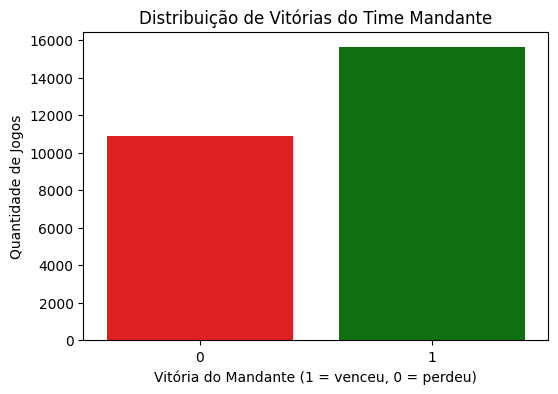

In [68]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="HOME_TEAM_WINS",
    data=df,
    hue="HOME_TEAM_WINS",
    palette={1: "green", 0: "red"},
    legend=False
)

plt.title("Distribuição de Vitórias do Time Mandante")
plt.xlabel("Vitória do Mandante (1 = venceu, 0 = perdeu)")
plt.ylabel("Quantidade de Jogos")

plt.show()

Observa-se que a quantidade de vitórias do time mandante é superior à de derrotas, indicando uma vantagem associada ao fator casa. Esse resultado sugere que jogar em casa é um fator de influência positiva para o desempenho das equipes.

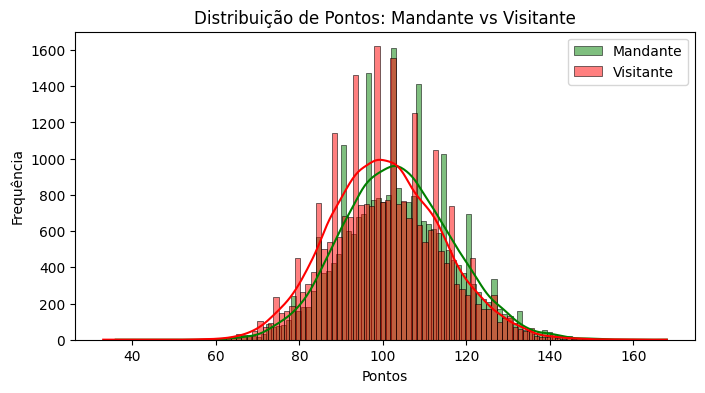

In [69]:
plt.figure(figsize=(8,4))

sns.histplot(df["PTS_home"], label="Mandante", kde=True, color="green")
sns.histplot(df["PTS_away"], label="Visitante", kde=True, color="red")

plt.title("Distribuição de Pontos: Mandante vs Visitante")
plt.xlabel("Pontos")
plt.ylabel("Frequência")
plt.legend()

plt.show()

A distribuição de pontos entre mandantes e visitantes apresenta comportamento semelhante, com leve tendência de maior pontuação por parte dos mandantes. No entanto, a grande sobreposição entre as distribuições indica que a pontuação isolada não é suficiente para explicar o resultado das partidas.

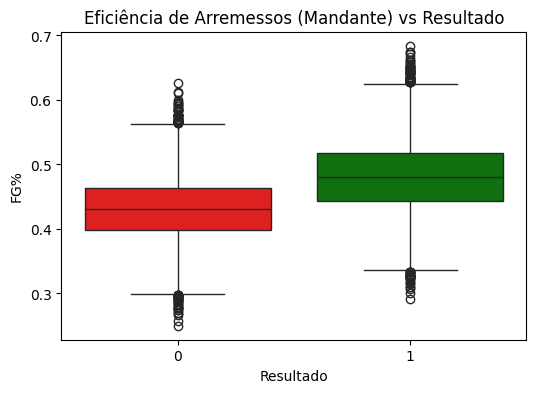

In [70]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="HOME_TEAM_WINS",
    y="FG_PCT_home",
    data=df,
    hue="HOME_TEAM_WINS",
    palette={1: "green", 0: "red"},
    legend=False
)

plt.title("Eficiência de Arremessos (Mandante) vs Resultado")
plt.xlabel("Resultado")
plt.ylabel("FG%")

plt.show()

A análise da eficiência de arremessos (FG%) evidencia uma diferença clara entre jogos vencidos e perdidos pelo mandante. Jogos vencidos apresentam maior aproveitamento, indicando que a eficiência ofensiva é um fator relevante para o sucesso das equipes.

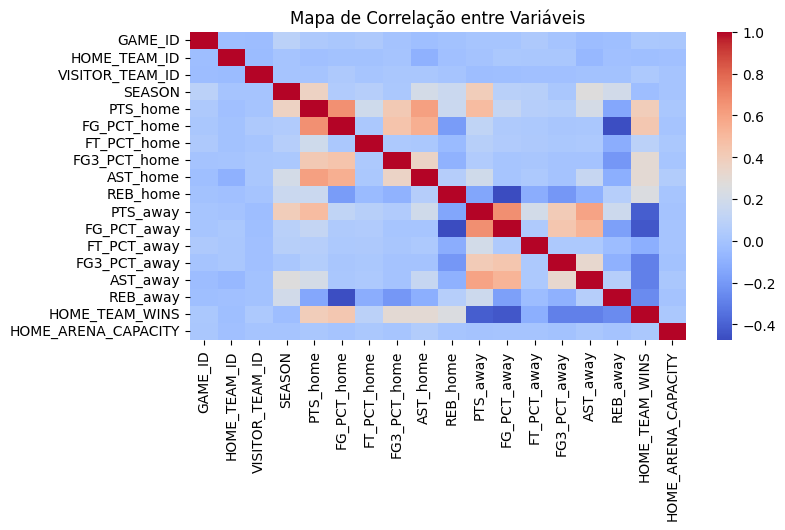

In [71]:
plt.figure(figsize=(8,4))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.title("Mapa de Correlação entre Variáveis")
plt.show()

O mapa de correlação mostra que a eficiência de arremessos possui relação mais forte com o resultado das partidas do que outras variáveis. Observa-se também uma relação inversa entre métricas de mandante e visitante, como rebotes de um dos times e eficiência de arremessos do outros, reforçando a importância do desempenho relativo entre as equipes.

### Criação de variáveis de desempenho relativo

Para aprofundar a análise, foram criadas variáveis que representam a diferença entre as métricas dos times mandantes e visitantes em cada partida.

Essa abordagem permite avaliar o desempenho relativo entre as equipes, sendo mais informativa do que a análise de métricas absolutas, uma vez que o resultado do jogo depende da comparação direta entre os dois times.

As variáveis criadas incluem diferenças de pontuação, eficiência de arremessos (FG%), assistências e rebotes.

In [72]:
df["PTS_diff"] = df["PTS_home"] - df["PTS_away"]
df["FG_PCT_diff"] = df["FG_PCT_home"] - df["FG_PCT_away"]
df["AST_diff"] = df["AST_home"] - df["AST_away"]
df["REB_diff"] = df["REB_home"] - df["REB_away"]

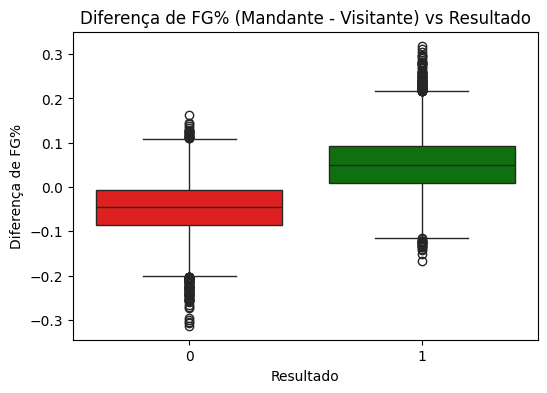

In [73]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="HOME_TEAM_WINS",
    y="FG_PCT_diff",
    data=df,
    hue="HOME_TEAM_WINS",
    palette={1: "green", 0: "red"},
    legend=False
)

plt.title("Diferença de FG% (Mandante - Visitante) vs Resultado")
plt.xlabel("Resultado")
plt.ylabel("Diferença de FG%")

plt.show()

Observa-se uma clara separação entre vitórias e derrotas em relação à diferença de eficiência de arremessos. Jogos em que o time mandante venceu estão associados, em sua maioria, a valores positivos de diferença de FG%, enquanto derrotas apresentam valores predominantemente negativos.

Esse comportamento evidencia que o desempenho relativo na eficiência de arremessos entre as equipes é um fator determinante para o resultado das partidas, mais do que o desempenho isolado de apenas um dos times.

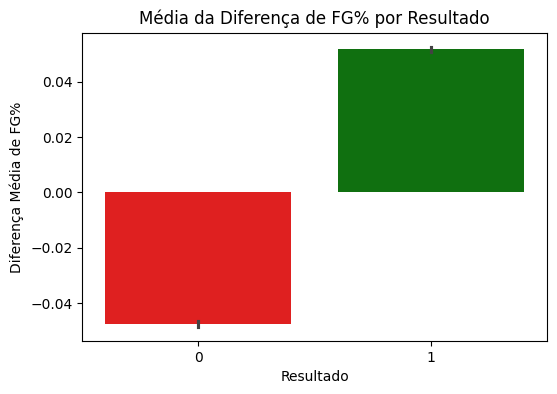

In [74]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="HOME_TEAM_WINS",
    y="FG_PCT_diff",
    data=df,
    hue="HOME_TEAM_WINS",
    palette={1: "green", 0: "red"},
    legend=False
)

plt.title("Média da Diferença de FG% por Resultado")
plt.xlabel("Resultado")
plt.ylabel("Diferença Média de FG%")

plt.show()

A análise das médias reforça o padrão observado anteriormente: jogos vencidos pelo mandante apresentam, em média, diferença positiva de FG%, enquanto jogos perdidos apresentam diferença negativa.

Esse resultado consolida a hipótese de que não apenas a eficiência de arremessos é importante, mas principalmente a superioridade relativa nessa métrica em relação ao adversário, sendo um dos principais fatores associados à vitória.

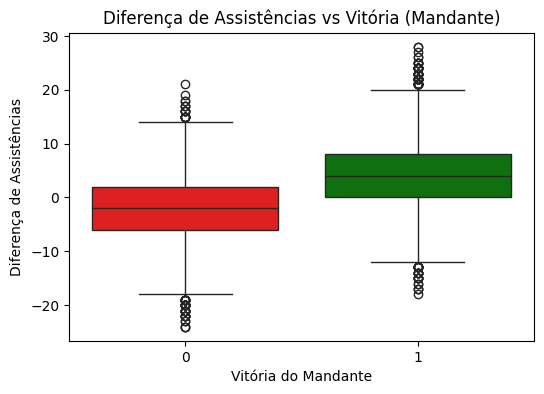

In [75]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="HOME_TEAM_WINS",
    y="AST_diff",
    data=df,
    hue="HOME_TEAM_WINS",
    palette={1: "green", 0: "red"},
    legend=False)

plt.title("Diferença de Assistências vs Vitória (Mandante)")
plt.xlabel("Vitória do Mandante")
plt.ylabel("Diferença de Assistências")

plt.show()

Observa-se uma relação consistente entre a diferença de assistências e o resultado da partida. Jogos vencidos pelo time mandante tendem a apresentar valores positivos de diferença de assistências, enquanto derrotas estão associadas, em média, a valores negativos.

Esse padrão indica que equipes que distribuem melhor a bola e apresentam maior volume de assistências em relação ao adversário possuem maior probabilidade de vitória. A diferença de assistências pode ser interpretada como um indicador de jogo coletivo e qualidade na criação de oportunidades ofensivas.

Além disso, embora exista alguma sobreposição entre os grupos, a mediana das vitórias é significativamente superior à das derrotas, reforçando que o desempenho relativo nessa métrica contribui de forma relevante para o desfecho das partidas.

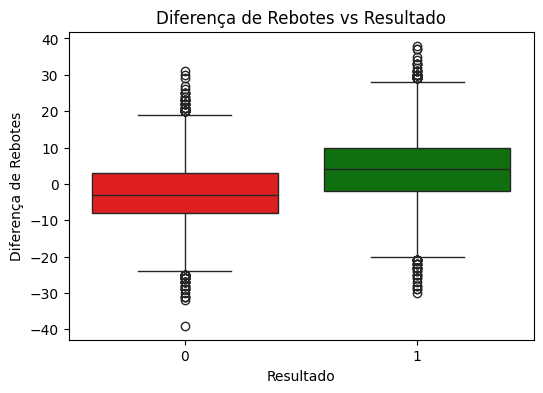

In [76]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="HOME_TEAM_WINS",
    y="REB_diff",
    data=df,
    hue="HOME_TEAM_WINS",
    palette={1: "green", 0: "red"},
    legend=False
)

plt.title("Diferença de Rebotes vs Resultado")
plt.xlabel("Resultado")
plt.ylabel("Diferença de Rebotes")

plt.show()

A diferença de rebotes também apresenta um padrão consistente em relação ao resultado das partidas. Jogos vencidos pelo mandante tendem a apresentar valores positivos, enquanto derrotas apresentam valores negativos, embora com maior dispersão em comparação a outras métricas.

Esse resultado sugere que, apesar de os rebotes contribuírem para o desempenho da equipe — especialmente ao gerar mais posses de bola — seu impacto no resultado é relevante, porém menos determinante do que métricas diretamente relacionadas à eficiência ofensiva.

### **Análise da influência da capacidade das arenas no desempenho dos times mandantes**

Como análise complementar, busca-se avaliar se a capacidade das arenas possui alguma relação com o desempenho das equipes mandantes, especificamente em relação à probabilidade de vitória.

A hipótese considera que arenas maiores podem estar associadas a maior presença de torcida, o que potencialmente poderia influenciar o desempenho das equipes jogando em casa.

A variável de capacidade das arenas apresenta valores ausentes para algumas franquias. Para esta análise, optou-se por considerar apenas os registros com valores disponíveis, evitando a imputação de dados, uma vez que a capacidade da arena é uma característica fixa e específica de cada equipe.

Dessa forma, os resultados devem ser interpretados considerando a redução do volume de dados analisados.

In [77]:
df_arena = df.dropna(subset=["HOME_ARENA_CAPACITY"])

df_arena.count()

,0
GAME_DATE_EST,23065
GAME_ID,23065
GAME_STATUS_TEXT,23065
HOME_TEAM_ID,23065
VISITOR_TEAM_ID,23065
SEASON,23065
PTS_home,23065
FG_PCT_home,23065
FT_PCT_home,23065
FG3_PCT_home,23065


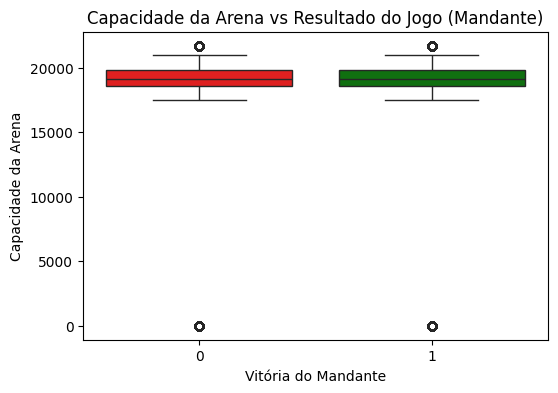

In [78]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="HOME_TEAM_WINS",
    y="HOME_ARENA_CAPACITY",
    data=df_arena,
    hue="HOME_TEAM_WINS",
    palette={1: "green", 0: "red"},
    legend=False)

plt.title("Capacidade da Arena vs Resultado do Jogo (Mandante)")
plt.xlabel("Vitória do Mandante")
plt.ylabel("Capacidade da Arena")
plt.show()

A distribuição dos valores apresenta comportamento semelhante entre os dois grupos, sem indicação clara de que arenas maiores estejam associadas a maior probabilidade de vitória.

Esse resultado sugere que o tamanho da arena, isoladamente, não exerce influência relevante sobre o desfecho das partidas.

## **Pré-processamento de Dados**

Nesta etapa, os dados são preparados para a aplicação de modelos de machine learning. O objetivo é garantir que as variáveis estejam no formato adequado, sem inconsistências e organizadas de forma a maximizar o desempenho dos modelos.

Serão realizadas etapas como seleção de variáveis, separação entre atributos e variável alvo, divisão entre conjuntos de treino e teste, além de transformações necessárias como padronização dos dados.

### **Seleção de Variáveis**

Foram selecionadas as variáveis mais relevantes para a predição do resultado das partidas, incluindo métricas de desempenho das equipes e variáveis derivadas que representam o desempenho relativo entre mandante e visitante.

In [79]:
features = [
    "PTS_home", "PTS_away",
    "FG_PCT_home", "FG_PCT_away",
    "AST_home", "AST_away",
    "REB_home", "REB_away",
    "FG_PCT_diff", "PTS_diff", "AST_diff", "REB_diff"
]

X = df[features]
y = df["HOME_TEAM_WINS"]

### **Divisão dos dados em treino e teste**

Os dados foram divididos em conjuntos de treino e teste, permitindo avaliar o desempenho do modelo em dados não utilizados durante o treinamento.

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [81]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (18586, 12)
Dimensões de X_test: (7966, 12)
Dimensões de y_train: (18586,)
Dimensões de y_test: (7966,)


### **Padronização das variáveis**

A padronização dos dados foi aplicada para garantir que todas as variáveis estejam na mesma escala, evitando que variáveis com maior magnitude influenciem desproporcionalmente o modelo.

Foi utilizado o método StandardScaler, que transforma os dados para média zero e desvio padrão igual a um.

In [82]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [84]:
X_train_scaled_df.head()

,PTS_home,PTS_away,FG_PCT_home,FG_PCT_away,AST_home,AST_away,REB_home,REB_away,FG_PCT_diff,PTS_diff,AST_diff,REB_diff
0,-0.259728,0.621964,-1.076018,0.344845,-0.929928,1.246634,-1.565140,0.745688,-1.024650,-0.865311,-1.661081,-1.690038
1,0.947663,-0.720061,0.585737,-0.591344,0.992570,-0.681302,0.697475,-1.241295,0.844846,1.631348,1.278043,1.412003
2,0.268506,-0.570947,0.921624,0.902958,-0.160929,-0.102921,-0.660094,-1.394140,0.025341,0.823606,-0.044563,0.525706
3,-0.184266,-1.018288,-0.722453,-0.249275,-0.737678,-1.259683,1.602521,-0.477071,-0.345997,0.823606,0.396306,1.522790
4,0.947663,0.323737,0.355920,-0.123249,-0.737678,-0.102921,-0.961776,0.134309,0.345460,0.603312,-0.485432,-0.803740


In [85]:
X_train_scaled_df.describe()

,PTS_home,PTS_away,FG_PCT_home,FG_PCT_away,AST_home,AST_away,REB_home,REB_away,FG_PCT_diff,PTS_diff,AST_diff,REB_diff
count,1.858600e+04,1.858600e+04,1.858600e+04,1.858600e+04,1.858600e+04,1.858600e+04,1.858600e+04,1.858600e+04,1.858600e+04,1.858600e+04,1.858600e+04,1.858600e+04
mean,2.806082e-16,-2.187712e-16,-4.384981e-16,6.915807e-16,2.385552e-16,-1.758580e-16,-4.195742e-17,4.205300e-18,-4.740520e-17,-2.102650e-17,3.670080e-17,-1.567430e-17
std,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00,1.000027e+00
min,-3.353668e+00,-3.478667e+00,-3.727754e+00,-3.705973e+00,-3.044674e+00,-3.187619e+00,-4.280278e+00,-3.228278e+00,-4.149012e+00,-4.390007e+00,-3.718469e+00,-4.459717e+00
25%,-7.124995e-01,-7.200605e-01,-6.870964e-01,-6.633583e-01,-7.376778e-01,-6.813023e-01,-6.600937e-01,-6.299156e-01,-6.661163e-01,-7.184488e-01,-6.323878e-01,-6.929532e-01
50%,-3.334195e-02,-4.904808e-02,-1.532317e-02,-1.522744e-02,3.132100e-02,-1.029215e-01,-5.672972e-02,-1.853612e-02,-2.686892e-04,8.929397e-02,-4.456286e-02,-2.823028e-02
75%,6.458156e-01,6.965213e-01,6.918065e-01,6.689107e-01,6.080701e-01,6.682530e-01,6.974752e-01,5.928434e-01,6.783837e-01,6.033121e-01,6.902183e-01,6.364927e-01
max,4.871685e+00,5.020824e+00,3.714786e+00,4.269638e+00,5.222063e+00,3.945745e+00,4.317659e+00,5.942414e+00,3.853965e+00,5.156044e+00,3.923256e+00,3.960107e+00


Observa-se que, após a padronização, as variáveis passam a apresentar média próxima de zero e desvio padrão unitário, conforme esperado.

Além disso, nota-se que o formato da distribuição dos dados é preservado, indicando que a padronização não altera as características estatísticas das variáveis, mas apenas reescala os valores, permitindo maior comparabilidade entre diferentes métricas.

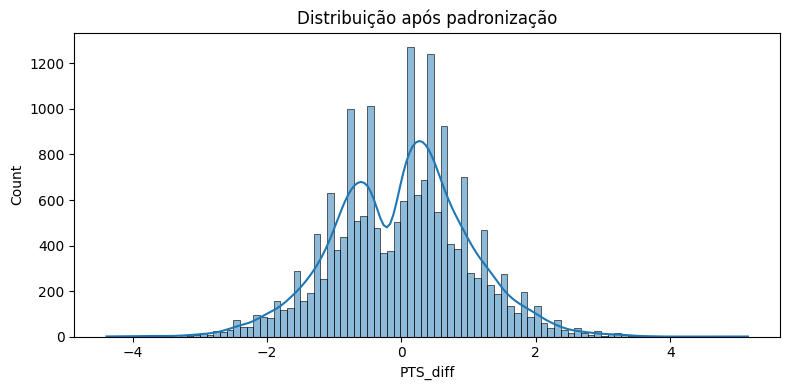

In [86]:
plt.figure(figsize=(8,4))
sns.histplot(X_train_scaled_df["PTS_diff"], kde=True)
plt.title("Distribuição após padronização")
plt.tight_layout()
plt.show()

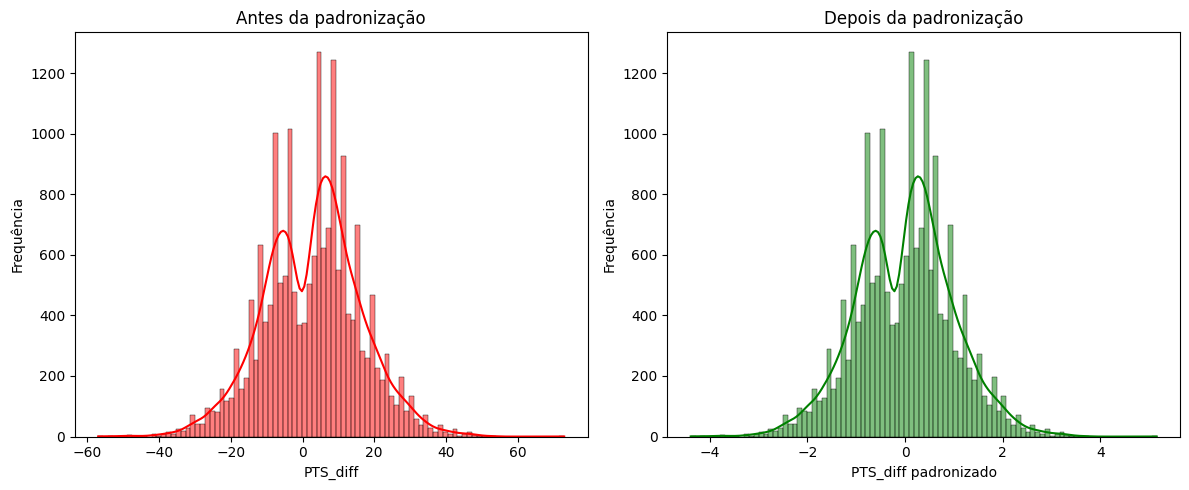

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(X_train["PTS_diff"], kde=True, ax=axes[0], color="red")
axes[0].set_title("Antes da padronização")
axes[0].set_xlabel("PTS_diff")
axes[0].set_ylabel("Frequência")

sns.histplot(X_train_scaled_df["PTS_diff"], kde=True, ax=axes[1], color="green")
axes[1].set_title("Depois da padronização")
axes[1].set_xlabel("PTS_diff padronizado")
axes[1].set_ylabel("Frequência")

plt.tight_layout()

plt.show()

A distribuição da variável após padronização mantém seu formato original, porém centralizada em torno de zero, indicando que a transformação preservou a estrutura dos dados.

As etapas de pré-processamento foram fundamentais para garantir a qualidade e consistência dos dados utilizados na análise. Foram tratadas inconsistências, ajustados formatos e aplicada a padronização das variáveis numéricas, permitindo que todas contribuíssem de forma equilibrada para a análise e possíveis modelos preditivos.

A escolha pela padronização, em detrimento da normalização, se deu pela presença de variáveis com diferentes escalas e pela maior robustez dessa técnica em relação a valores extremos.

## **Análise das Hipóteses**

A partir da análise exploratória dos dados, foi possível avaliar as hipóteses inicialmente levantadas:

- A hipótese de que times mandantes possuem maior probabilidade de vitória foi confirmada, evidenciando a existência de vantagem associada ao fator casa;

- Observou-se que equipes vencedoras apresentam, em média, melhores indicadores de desempenho ofensivo, como maior eficiência de arremessos e consequentemente de pontuação;

- A análise das variáveis de diferença demonstrou que o desempenho relativo entre as equipes é um dos principais fatores explicativos do resultado das partidas, com clara separação entre vitórias e derrotas;

- Métricas de eficiência ofensiva, como FG%, mostraram maior capacidade explicativa em relação ao resultado quando comparadas a métricas como rebotes, que apresentaram maior dispersão;

- A hipótese relacionada à capacidade das arenas não foi confirmada, uma vez que não foram observadas diferenças relevantes entre jogos vencidos e perdidos em função dessa variável.

## **Conclusão**

Este trabalho teve como objetivo analisar os fatores associados ao resultado de partidas de basquete, utilizando dados estatísticos das equipes mandantes e visitantes.

A análise exploratória permitiu identificar padrões consistentes entre o desempenho das equipes e o resultado das partidas. Em especial, verificou-se que a vantagem do time mandante se confirma nos dados, refletindo uma maior frequência de vitórias.

Além disso, foi possível observar que métricas relacionadas à eficiência ofensiva, como o percentual de acerto em arremessos (FG%), possuem forte relação com o resultado das partidas. No entanto, o principal insight obtido foi que o desempenho relativo entre as equipes — representado pelas diferenças entre suas métricas — é mais relevante do que os valores absolutos.

Por outro lado, variáveis estruturais, como a capacidade das arenas, não demonstraram impacto significativo no resultado dos jogos, indicando que o desempenho em quadra é o principal fator determinante.

Embora alguns dos resultados possam parecer intuitivos, a análise de dados permitiu validar quantitativamente essas relações, oferecendo maior robustez às conclusões.

Por fim, este estudo fornece uma base sólida para aplicações futuras de modelos preditivos, podendo ser expandido com a inclusão de novas variáveis e técnicas mais avançadas de modelagem.